# How do we make a wavelength calibration?

This notebook builds on the skills of [measuring line diagnostics](lines.ipynb) to establish a wavelength calibration for a spectrum image. Here, we'll work with an extracted HeNeAr emission line spectrum from the SBO 24" spectrograph, tying many emission lines together into a coherent model for the relationship between pixel and wavelength. 

## Start with a Reference List of Wavelengths

For a wavelength calibration, we need to know the actual wavelengths of the lines we're looking at. Here are a few resources that might help. 

### Quantitative Lists of Wavelengths

To avoid having to type in lots of individual wavelengths, you may want a list of wavelengths you can read into Python arrays. Here are a few:

- [HeNeAr lines at SBO](data/HeNeAr-wavelengths-sbo.ecsv) = a list of lines culled from an ancient printed wavelength-calibration manual for the SBO 24" spectrograph. These have the advantage that they are all probably lines that have been observed at least once from SBO.
- [a whole bunch of random lists of lines](https://github.com/jradavenport/pykosmos/tree/main/pykosmos/resources/linelists) = a directory hidden inside the repository for [PyKOSMOS](https://github.com/jradavenport/pykosmos/) that had oodles of different lists of lines. Many come from the historical guts of [IRAF](https://iraf-community.github.io). 
- [ASDTools](https://github.com/Autumn10677/ASDtools) to access raw line lists, and maybe construct wavelength references from scratch.

### Visual References for Wavelengths

An initial wavelength calibration typically requires matching up a few pairs of "this pixel corresponds to this wavelength". To help with that, here are some reference images that might help for arc lamps:

- [SBO wavelength references](https://github.com/zkbt/astr3520-handbook/tree/main/data/sbo/wavelength-references) = plots showing the wavelengths that are likely visible with the SBO 24" spectrograph at different grating angles. This folder also includes with some context animations showing how the emission lamps and the solar spectrum change with grating angle.
- [APO/KOSMOS Guide](https://www.apo.nmsu.edu/mainpage/kosmos/kosmosguide/#4p2) = images and plots of wavelength references observed with KOSMOS, including low, center, and high positions
- [pykosmos Wavelength Templates](https://github.com/jradavenport/kosmos-arc/tree/main/figures) = additional plots labeling wavelengths and pixels for all KOSMOS slit positions and arclamps



## Import `specutils` and `astropy.modeling`

For constructing a wavelength calibration, we'll rely on some handy analysis and fitting tools from the `astropy`-affiliated packages. Let's import that (along with other more familiar packages) here.

In [1]:
# do some basic imports
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import glob
from astropy.table import QTable


# make matplotlib plots play nicely with astropy units
from astropy.visualization import quantity_support
quantity_support();

# specutils
from specutils import Spectrum
from astropy.nddata import StdDevUncertainty
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from specutils.analysis import centroid, line_flux, fwhm
from specutils.fitting import estimate_line_parameters, fit_lines
from astropy.modeling import models

# hide some annoying warnings (comment out if you're having bugs!)
import warnings
warnings.catch_warnings()
warnings.simplefilter('ignore')

from IPython.display import Image, display

# allow interactive plots
%matplotlib ipympl

## Load a HeNeAr Wavelength Calibration Spectrum

Let's load an example 1D spectrum from the SBO spectrograph into a data table. This spectrum was produced by averaging together a few rows from the center of a 2D spectrograph image. As we read it here, `astropy` units are attached to each column. 

In [2]:
uncalibrated = QTable.read('data/sbo/extracted-HeNeAr-pixels.ecsv', format='ascii.ecsv')
uncalibrated

wavelength_pixel,flux,uncertainty
pix,ph / (pix s),ph / (pix s)
float64,float64,float64
0.0,13.566,5.782850542768679
1.0,5.32,5.019498022711036
2.0,3.99,4.885218562152567
3.0,6.118,5.098368405676467
4.0,7.448,5.22717518359582
5.0,23.40800000000001,6.579009074321148
6.0,-1.596,4.275436866566971
7.0,10.374,5.499941854238098


This spectrum has the wavelength dimension still in units of pixels, representing the column along the detector. By the end of this notebook, we'll convert these pixels into actual wavelengths. Let's start by converting our data table into a `specutils.Spectrum` object.

In [3]:
# create a specutils "Spectrum" object, including uncertainty that can be propagated
spectrum = Spectrum(spectral_axis=uncalibrated['wavelength_pixel'], 
                    flux=uncalibrated['flux'],
                    uncertainty=StdDevUncertainty(uncalibrated['uncertainty']))

spectrum

<Spectrum(flux=[13.566 ... 7.182] ph / (pix s) (shape=(11656,), mean=94.90942 ph / (pix s)); spectral_axis=<SpectralAxis [0.0000e+00 1.0000e+00 2.0000e+00 ... 1.1653e+04 1.1654e+04 1.1655e+04] pix> (length=11656); uncertainty=StdDevUncertainty)>

This spectrum object still has no wavelength calibration, so the `spectral_axis` is still in units of pixels. Let's write another little wrapper to be able to plot `Spectrum` objects like this.

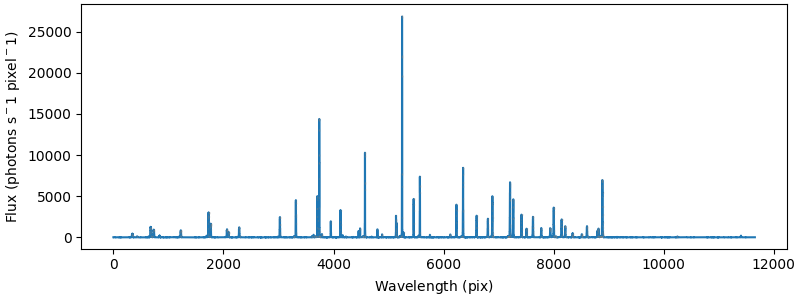

In [4]:
def plot_spectrum(spectrum, **kw):
    '''
    Make a plot of a specutils.Spectrum object.

    Parameters 
    ----------
    spectrum : specutils.Spectrum
        The main input should be a spectrum stored 
        as a `specutils` object, with `.spectral_axis`
        and `.flux` attributes attached.
    **kw : dict 
        All other keywords will be passed into the 
        `plt.step` plotting function. 
    '''

    # extract the arrays we need
    x = spectrum.spectral_axis
    flux = spectrum.flux
    uncertainty = spectrum.uncertainty.quantity

    # plot the spectrum
    plt.step(x, flux, where='mid', **kw)
    plt.errorbar(x, flux, uncertainty, linewidth=0, elinewidth=1, color='gray', alpha=0.5)

    # add some labels
    plt.xlabel(f'Wavelength ({x.unit.to_string(format="latex_inline")})')
    plt.ylabel('Flux (photons s$^-1$ pixel$^-1$)')

plt.figure(figsize=(8, 3), constrained_layout=True)
plot_spectrum(spectrum)

## Fit Lots of Lines

To fit a wavelength calibration, we're going to need to estimate the centroids of as many emission lines as possible. Fortunately, `specutils` has some handy tools for [finding emission lines](https://specutils.readthedocs.io/en/stable/fitting.html#line-finding); here we'll use `find_lines_derivative` to identify peaks from zero-crossings in the derivative, for lines with flux above some threshold.

In [5]:
from specutils.fitting import find_lines_derivative

# generate intital guesses for the positions of many lines
lots_of_lines = find_lines_derivative(spectrum, flux_threshold=50*u.photon/u.s/u.pixel)
lots_of_lines

line_center,line_type,line_center_index
pix,,
float64,str8,int64
337.0,emission,337
346.0,emission,346
430.0,emission,430
434.0,emission,434
640.0,emission,640
676.0,emission,676
680.0,emission,680
696.0,emission,696


Now that we have initial guesses, we can loop through each line and refine our estimates of the line centers from these rough integer values to more precise centroids. 

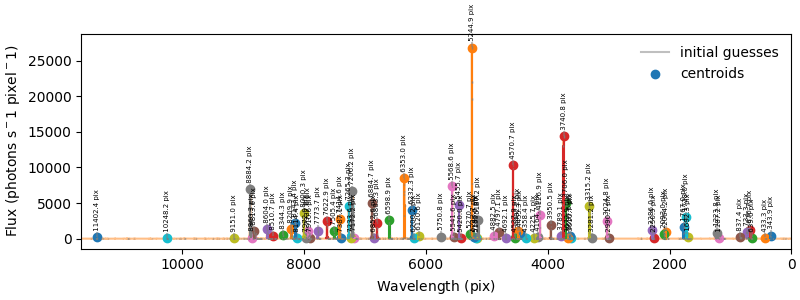

In [6]:
plt.figure(figsize=(8, 3), constrained_layout=True)

# how wide around each line guess should consider for a centroid?
line_centroiding_window = 10*u.pixel

# create some empty columns in the table of lines
lots_of_lines['centroid'] = np.nan*u.pixel
lots_of_lines['fwhm'] = np.nan*u.pixel
lots_of_lines['flux'] = np.nan*u.photon/u.s
lots_of_lines['peak'] = np.nan*u.photon/u.s/u.pixel

# loop through lines, find centroids for each
for i in range(len(lots_of_lines)):

    # start from an initial guess   
    line_guess = lots_of_lines['line_center'][i]

    # extract a region around the line
    sub_region = SpectralRegion(line_guess - line_centroiding_window, line_guess + line_centroiding_window)
    sub_spectrum = extract_region(spectrum, sub_region)
    
    # extract some line diagnostics (which won't be perfect for blended lines)
    this_centroid = centroid(sub_spectrum)
    this_fwhm = fwhm(sub_spectrum)
    this_flux = line_flux(sub_spectrum)
    this_peak = np.max(sub_spectrum.flux)

    # store them in the table    
    lots_of_lines['centroid'][i] = this_centroid
    lots_of_lines['fwhm'][i] = this_fwhm
    lots_of_lines['flux'][i] = this_flux
    lots_of_lines['peak'][i] = this_peak

# smoosh together lines that are too close to each other
too_close_to_others = np.zeros(len(lots_of_lines)).astype(bool)
for i in range(len(lots_of_lines)):
    this_centroid = lots_of_lines['centroid'][i]
    this_flux = lots_of_lines['flux'][i]
    is_nearby_to_this_line = np.abs(lots_of_lines['centroid'] - this_centroid) <= line_centroiding_window*2

    if sum(is_nearby_to_this_line) > 1:
        is_fainter_than_this_line = lots_of_lines['flux'] < this_flux
        too_close_to_others += is_nearby_to_this_line*is_fainter_than_this_line
row_numbers_to_remove = np.nonzero(too_close_to_others)[0]
lots_of_lines.remove_rows(row_numbers_to_remove)

# plot the individual sub-spectra an
for i in range(len(lots_of_lines)):
    # start from an initial guess   
    this_centroid = lots_of_lines['centroid'][i]
    this_peak = lots_of_lines['peak'][i]

    # extract a region around the line
    sub_region = SpectralRegion(this_centroid - line_centroiding_window, this_centroid + line_centroiding_window)
    sub_spectrum = extract_region(spectrum, sub_region)

    # plot each sub-spectrum + line guess + measured centroid
    plot_spectrum(sub_spectrum)
    if i == 0:
        label = 'initial guesses'
    else:
        label = None
    #plt.axvline(this_centroid, ymin=0.9, alpha=0.5, linestyle='--', color='gray', label=label)
    offset = 200 
    height = 400
    plt.plot(np.ones(2)*this_centroid, np.array([offset, offset + height]) + this_peak.value, alpha=0.5, color='gray', label=label)
    plt.text(this_centroid,  offset+height + this_peak.value, f' {this_centroid:.1f}', rotation=90, fontsize=5, ha='center', va='bottom')
    if i == 0: 
        label = 'centroids'
    else: 
        label = None
    plt.scatter(this_centroid, this_peak, label=label)


# plot the full spectrum behind, for reference
plot_spectrum(spectrum, alpha=0.5, zorder=-100)
plt.legend(frameon=False, loc='upper right')
plt.xlim(len(uncalibrated), 0);

Take a moment to zoom in on a few lines. Check that you're finding lots of lines, and check that the centroid positions for those lines seem to make sense. If we look at the table below, we'll see that it's now populated with our precisely measured line diagnostics for every line we started with. 

## ⚠️ Eep! things get sketchy from here! ⚠️

In [7]:
'''1224*u.pixel = 8521*u.AA
8885~pixels = 5852.5*u.AA'''

'1224*u.pixel = 8521*u.AA\n8885~pixels = 5852.5*u.AA'

In [8]:
lots_of_lines['manually-matched-wavelength'] = np.nan*u.AA
lots_of_lines['automatically-matched-wavelength'] = np.nan*u.AA

lots_of_lines.add_index('line_center_index')
lots_of_lines.loc.with_index('line_center_index')[8884]['manually-matched-wavelength'] = 5853*u.AA
lots_of_lines.loc.with_index('line_center_index')[4882]['manually-matched-wavelength'] = 7147.04*u.AA
lots_of_lines.loc.with_index('line_center_index')[676]['manually-matched-wavelength'] = 8424.6*u.AA

In [9]:
lots_of_lines.show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [10]:
known_lines = QTable.read('data/HeNeAr-wavelengths-sbo.ecsv')
reference_wavelengths = known_lines['wavelength']

Model: Polynomial1D
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Degree: 2
Parameters:
            c0                 c1                   c2          
         Angstrom        Angstrom / pix      Angstrom / pix2    
    ----------------- ------------------- ----------------------
    8622.251562801626 -0.2904659295646809 -2.390890845886442e-06


NameError: name 'matched_wavelength' is not defined

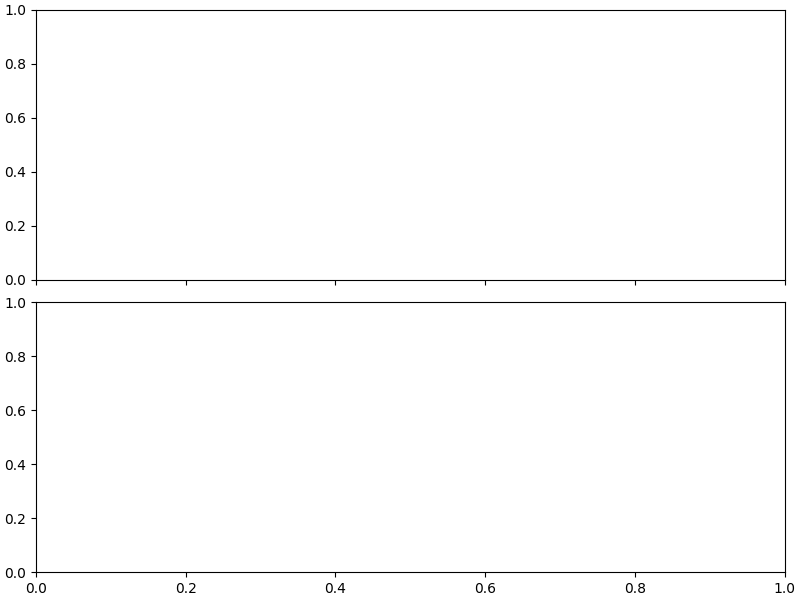

In [11]:


from astropy.modeling import models, fitting
fit = fitting.LinearLSQFitter()


ok = np.isfinite(lots_of_lines['manually-matched-wavelength'])

initial_wavelength_function = fit(models.Polynomial1D(degree=2), 
                                  lots_of_lines[ok]['centroid'], 
                                  lots_of_lines[ok]['manually-matched-wavelength'])

print(initial_wavelength_function)
fi, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True, constrained_layout=True)


residuals = matched_wavelength - initial_wavelength_function(matched_pixel)
smooth_pixel_grid = np.linspace(np.min(spectrum.spectral_axis), np.max(spectrum.spectral_axis))
plt.sca(ax[0])
plt.ylabel('$\sf \lambda = $ Wavelength ($\AA$)')
plt.scatter(matched_pixel, matched_wavelength)
plt.plot(smooth_pixel_grid, initial_wavelength_function(smooth_pixel_grid))



guess_for_other_lines = wavelength_function(lots_of_lines['centroid'])
wavelength_threshold = 50*u.AA
for i in range(len(reference_wavelengths)):
    distance_to_lines = np.abs(reference_wavelengths - guess_for_other_lines[i])
    i_closest = np.argmin(distance_to_lines)

    if distance_to_lines[i_closest] < wavelength_threshold:
        lots_of_lines['wavelength'][i] = reference_wavelengths[i_closest]

plt.scatter(lots_of_lines['centroid'], lots_of_lines['wavelength'])


plt.sca(ax[1])
more_residuals = lots_of_lines['wavelength'] - wavelength_function(lots_of_lines['centroid'])

plt.scatter(lots_of_lines['centroid'],more_residuals )

plt.axhline(0)
plt.xlabel('Wavelength Pixel');



In [ ]:
reference_wavelengths[i_closest]

In [ ]:
np.gradient?